In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skgstat import Variogram

pa_gs = pd.read_csv('data/pa_data.csv')

<Figure size 1000x600 with 0 Axes>

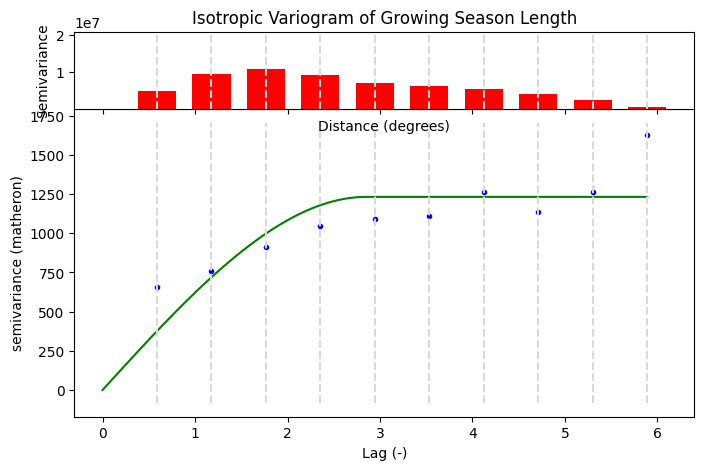

In [8]:
coords = pa_gs[['latitude', 'longitude']].values
values = pa_gs['growing_season_length'].values

vario = Variogram(coords, values)

plt.figure(figsize=(10, 6))
vario.plot()
plt.xlabel('Distance (degrees)')
plt.ylabel('Semivariance')
plt.title('Isotropic Variogram of Growing Season Length')
plt.show()

In [3]:
print(vario.bins)
print(vario.values) 

[0.58891095 1.17782189 1.76673284 2.35564379 2.94455473 3.53346568
 4.12237663 4.71128758 5.30019852 5.88910947]
[204 199 166 ... 190 203 192]


If there is any spatial correlation between points in this data, it would be for points within 2 degrees of each other. Beyond that, there does not appear to be any significant correlation.

In [4]:
import scipy as sp
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = ['growing_season_length']
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico','sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']

def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        return X_cleaned, y_cleaned

def multiple_regression(data_subset, input_variables, predicted_variable):
    #performs a standardized multiple linear regression to create a model of y based on the variables within X.
    # Required Libraries: r2score, mean_absolute_error, and mean_squared_error from sklearn.metrics, 
    # train_test_split from sklearn.model_selection, linear_model from sklearn, and StandardScaler from sklearn.preprocessing

    X_cleaned, y_cleaned = remove_nulls(data_subset, input_variables, predicted_variable)

    #counts total data points included in regression
    tot_data_points = len(X_cleaned)
    
    #splits data into training and testing groups
    X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size = 0.2, random_state =0)

    #converts y_train, y_test, and y_cleaned into series
    y_train= y_train.squeeze()
    y_test= y_test.squeeze()
    y_cleaned = y_cleaned.squeeze()
    
    #scales input data to standardize to mean of 0 and standard deviation of 1
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.fit_transform(X_test)
    
    #creates multiple regression model based on training data
    regr = linear_model.LinearRegression()
    regr.fit(X_train_scaled, y_train)

    #calculates mean absolute error, mean squared error, and r squared score based on the predicted y
    y_predicted = regr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_predicted)
    mse = mean_squared_error(y_test, y_predicted)
    rmse = np.sqrt(mse)
    r_2_score = r2_score(y_test, y_predicted)
    n = len(y_cleaned)
    p = X_cleaned.shape[1]
    adj_r2_score = 1 - ((1 - r_2_score) * (n - 1) / (n - p - 1))
    y_std = y_cleaned.std().round(5)
    coefficients = pd.DataFrame(zip(X_cleaned.columns, X_cleaned.std().round(5), regr.coef_.round(5)))

    coefficients.columns = ['variable', 'var standard dev', 'coefficient']

    y_test = pd.DataFrame(y_test.reset_index())
    y_test = y_test.drop(y_test.columns[0], axis=1)
    y_predicted = pd.DataFrame(pd.Series(y_predicted))
    y_predicted = y_predicted.rename(columns={0: 'growing_season_length'}) 
    residuals = y_test.sub(y_predicted)
    
    results = [f'MAE = {mae}', f'MSE = {mse}', f'RMSE = {rmse}', f'R Squared = {r_2_score}', 
               f'Adj. R Squared = {adj_r2_score}', f'Total Data Points = {tot_data_points}',
               f'(Reference) predicted variable standard deviation = {y_std}', coefficients, f'Residuals:', residuals]
    display(results)
    return residuals, X_test

In [5]:
reg_residuals, X_tests = multiple_regression(pa_gs, X, y)

['MAE = 10.25825018564257',
 'MSE = 174.2708727493307',
 'RMSE = 13.201169370526639',
 'R Squared = 0.8111050764873684',
 'Adj. R Squared = 0.8098694381568057',
 'Total Data Points = 7233',
 '(Reference) predicted variable standard deviation = 31.23174',
                       variable  var standard dev  coefficient
 0                   dtr_annual           1.42052    -13.66920
 1                   dtr_spring           1.62191      0.44842
 2                   dtr_summer           1.85314      1.49569
 3                  tmax_annual           1.73240      7.83147
 4               prcp_annual_mm         210.58578    -14.00453
 5       prcp_growing_season_mm         170.51672     19.66358
 6               prcp_spring_mm          76.52566      3.04974
 7                     latitude           0.65895     -8.61432
 8                    longitude           1.76333      8.83282
 9                  elevation_m         164.23514     -4.29876
 10               dist_coast_km          60.51768   

<Figure size 1000x600 with 0 Axes>

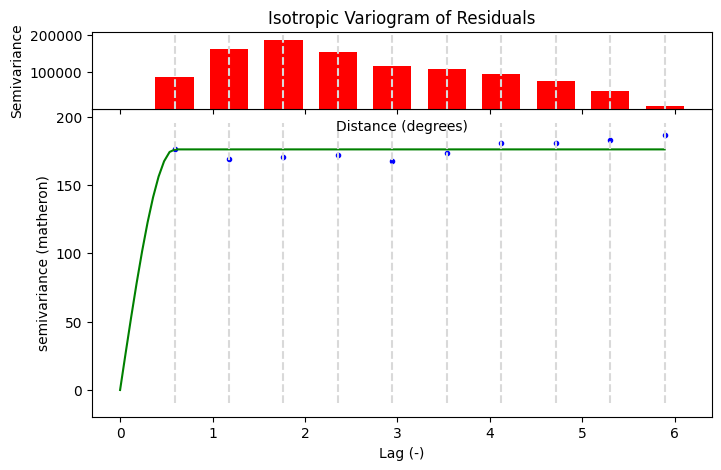

In [6]:
cleaned_latlon = X_tests[['latitude', 'longitude']]
coords = cleaned_latlon.values
values = reg_residuals.values

vario = Variogram(coords, values)

plt.figure(figsize=(10, 6))
vario.plot()
plt.xlabel('Distance (degrees)')
plt.ylabel('Semivariance')
plt.title('Isotropic Variogram of Residuals')
plt.show()